In [2]:
import ufl
from dolfinx import fem
from mpi4py import MPI
from dolfinx.io import gmsh
import vtk
import meshio
import numpy as np
from vtk.util.numpy_support import vtk_to_numpy
from scipy.spatial import cKDTree
from dolfinx import mesh, fem, io, plot
from scipy.interpolate import RBFInterpolator
from types import SimpleNamespace
import basix
import dolfinx.fem.petsc
from dolfinx.fem.petsc import NonlinearProblem
from pathlib import Path



# LOCAL FRAME
def normalize(v):
    return v / ufl.sqrt(ufl.dot(v, v))

def _local_frame_ufl(domain):
    t  = ufl.Jacobian(domain)
    t1 = ufl.as_vector([t[0, 0], t[1, 0], t[2, 0]])
    t2 = ufl.as_vector([t[0, 1], t[1, 1], t[2, 1]])
    e3 = normalize(ufl.cross(t1, t2))
    ey = ufl.as_vector([0, 1, 0])
    ez = ufl.as_vector([0, 0, 1])
    e1_trial = ufl.cross(ey, e3)
    norm_e1  = ufl.sqrt(ufl.dot(e1_trial, e1_trial))
    e1 = ufl.conditional(ufl.lt(norm_e1, 0.5), ez, normalize(e1_trial))
    e2 = normalize(ufl.cross(e3, e1))
    return e1, e2, e3

def local_frame(domain, gdim):
    FRAME  = _local_frame_ufl(domain)
    VT     = fem.functionspace(domain, ("DG", 0, (gdim,)))
    V0, _  = VT.sub(0).collapse()
    BASIS  = [fem.Function(VT, name=f"Basis_vector_e{i+1}") for i in range(gdim)]
    for i in range(gdim):
        e_exp = fem.Expression(FRAME[i], V0.element.interpolation_points)
        BASIS[i].interpolate(e_exp)
    return BASIS[0], BASIS[1], BASIS[2]


# SHELL KINEMATICS
def hstack(vecs):
    return ufl.as_matrix([[vi[i] for i in range(len(vi))] for vi in vecs]).T

def tangent_projection(e1, e2):
    return hstack([e1, e2])

def tangential_gradient(w, P):
    return ufl.dot(ufl.grad(w), P)

def membrane_strain(u, P):
    t_gu = ufl.dot(P.T, tangential_gradient(u, P))
    return ufl.sym(t_gu), t_gu

def bending_strain(theta, e3, P):
    beta = ufl.cross(e3, theta)
    return ufl.sym(ufl.dot(P.T, tangential_gradient(beta, P)))

def shear_strain(u, theta, e3, P):
    beta = ufl.cross(e3, theta)
    return tangential_gradient(ufl.dot(u, e3), P) - ufl.dot(P.T, beta)

def compute_drilling_strain(t_gu, theta, e3):
    return (t_gu[0, 1] - t_gu[1, 0]) / 2 + ufl.dot(theta, e3)

def shell_strains(u, theta, e1, e2, e3):
    P                 = tangent_projection(e1, e2)
    eps, t_gu         = membrane_strain(u, P)
    kappa             = bending_strain(theta, e3, P)
    gamma             = shear_strain(u, theta, e3, P)
    drilling_strain   = compute_drilling_strain(t_gu, theta, e3)
    return eps, kappa, gamma, drilling_strain



# ISOTROPIC MATERIAL
def isotropic_material(thickness, young, poisson, domain):
    h        = fem.Constant(domain, float(thickness))
    E        = fem.Constant(domain, float(young))
    nu       = fem.Constant(domain, float(poisson))
    lmbda    = E * nu / (1 + nu) / (1 - 2 * nu)
    mu       = E / 2 / (1 + nu)
    lmbda_ps = 2 * lmbda * mu / (lmbda + 2 * mu)
    return SimpleNamespace(h=h, E=E, nu=nu, lmbda=lmbda, mu=mu, lmbda_ps=lmbda_ps, kind="isotropic")

# CLT COMPOSITE MATERIAL
def _Q_ply(E1, E2, G12, nu12):
    nu21 = nu12 * E2 / E1
    d    = 1 - nu12 * nu21
    return np.array([
        [ E1 / d,        nu12 * E2 / d,  0   ],
        [ nu12 * E2 / d, E2 / d,         0   ],
        [ 0,             0,              G12 ],
    ])


def _Qbar_ply(Q, angle_deg):
    a    = np.radians(angle_deg)
    c, s = np.cos(a), np.sin(a)
    T = np.array([
        [ c**2,   s**2,   2*c*s          ],
        [ s**2,   c**2,  -2*c*s          ],
        [-c*s,    c*s,    c**2 - s**2    ],
    ])
    R    = np.diag([1.0, 1.0, 2.0])
    Rinv = np.diag([1.0, 1.0, 0.5])
    return np.linalg.inv(T) @ Q @ R @ T @ Rinv

def compute_ABD(layup_angles, t_ply, E1, E2, G12, nu12):
    Q   = _Q_ply(E1, E2, G12, nu12)
    H   = t_ply * len(layup_angles)
    z   = -H / 2.0
    A   = np.zeros((3, 3))
    B   = np.zeros((3, 3))
    D   = np.zeros((3, 3))
    for angle in layup_angles:
        Qb = _Qbar_ply(Q, angle)
        z0, z1 = z, z + t_ply
        A += Qb * (z1 - z0)
        B += Qb * (z1**2 - z0**2) / 2.0
        D += Qb * (z1**3 - z0**3) / 3.0
        z  = z1
    return A, B, D, H

def clt_material(layup_angles, t_ply,E1, E2, G12, nu12,G13=None, G23=None, kappa_s=5/6):
    if G13 is None: G13 = G12
    if G23 is None: G23 = G12 * 0.5

    A_np, B_np, D_np, H = compute_ABD(layup_angles, t_ply, E1, E2, G12, nu12)

    max_B = np.abs(B_np).max()
    print(f"[CLT] Layup  : {layup_angles}")
    print(f"[CLT] H      : {H*1e3:.2f} mm")
    print(f"[CLT] max|B| : {max_B:.2e}  {'SYMMETRIC' if max_B < 1e-6 * A_np.max() else 'NON-SYMMETRIC'}")
    print(f"[CLT] A11    : {A_np[0,0]/1e6:.2f} MPa·m")
    print(f"[CLT] D11    : {D_np[0,0]:.4f} N·m²")

    As_np = kappa_s * H * np.array([
        [ G13, 0.0 ],
        [ 0.0, G23 ],
    ])

    # EFFECTIVE IN-PLANE SHEAR FOR DRILLING STABILISATION
    G_eff = float(A_np[2, 2]) / H

    return SimpleNamespace(
        kind   = "clt",
        H      = H,
        A_np   = A_np,
        B_np   = B_np,
        D_np   = D_np,
        As_np  = As_np,
        G_eff  = G_eff,
        A_ufl  = ufl.as_tensor(A_np),
        B_ufl  = ufl.as_tensor(B_np),
        D_ufl  = ufl.as_tensor(D_np),
        As_ufl = ufl.as_tensor(As_np),
    )

# VOIGT NOTATION
def to_voigt(e):
    return ufl.as_vector([e[0, 0], e[1, 1], 2.0 * e[0, 1]])


def from_voigt(v):
    return ufl.as_tensor([
        [v[0], v[2]],
        [v[2], v[1]],
    ])


# SHELL STRESS RESULTANTS
def _plane_stress_iso(mat, e):
    tdim = e.ufl_shape[0]
    return mat.lmbda_ps * ufl.tr(e) * ufl.Identity(tdim) + 2 * mat.mu * e


def stress_resultants(mat, eps, kappa, gamma):
    if mat.kind == "isotropic":
        N = mat.h * _plane_stress_iso(mat, eps)
        M = mat.h**3 / 12.0 * _plane_stress_iso(mat, kappa)
        Q = mat.mu * mat.h * gamma

    elif mat.kind == "clt":
        eps_v   = to_voigt(eps)
        kappa_v = to_voigt(kappa)

        N_v = ufl.dot(mat.A_ufl, eps_v) + ufl.dot(mat.B_ufl, kappa_v)
        M_v = ufl.dot(mat.B_ufl, eps_v) + ufl.dot(mat.D_ufl, kappa_v)

        N   = from_voigt(N_v)
        M   = from_voigt(M_v)
        Q   = ufl.dot(mat.As_ufl, gamma)

    else:
        raise ValueError(f"Unknown material kind: {mat.kind!r}")
    return N, M, Q


def drilling_terms(mat, domain, drilling_strain):
    h_mesh = ufl.CellDiameter(domain)

    if mat.kind == "isotropic":
        G_eff = mat.mu
    else:
        G_eff = fem.Constant(domain, mat.G_eff)

    h = mat.h if mat.kind == "isotropic" else fem.Constant(domain, mat.H)

    stiffness = G_eff * h**3 / h_mesh**2
    stress    = stiffness * drilling_strain
    return stiffness, stress


# IMPORT AND MAP OPENFOAM DATA
def import_foam_traction(foamfile, xdmffile, verbose=False):
    reader = vtk.vtkXMLPolyDataReader()
    reader.SetFileName(foamfile)
    reader.Update()
    poly = reader.GetOutput()

    tri = vtk.vtkTriangleFilter()
    tri.SetInputData(poly)
    tri.Update()
    poly = tri.GetOutput()

    points = vtk_to_numpy(poly.GetPoints().GetData())
    p      = vtk_to_numpy(poly.GetPointData().GetArray("p"))
    wss    = vtk_to_numpy(poly.GetPointData().GetArray("wallShearStress"))

    cells = poly.GetPolys()
    cells.InitTraversal()
    idList = vtk.vtkIdList()
    triangles = []
    while cells.GetNextCell(idList):
        triangles.append([idList.GetId(i) for i in range(3)])
    triangles = np.array(triangles)

    P0 = points[triangles[:, 0]]
    P1 = points[triangles[:, 1]]
    P2 = points[triangles[:, 2]]

    v1 = P1 - P0
    v2 = P2 - P0
    n  = np.cross(v1, v2)

    area = 0.5 * np.linalg.norm(n, axis=1)
    n_unit = n / np.linalg.norm(n, axis=1)[:, None]

    p_tri   = p[triangles].mean(axis=1)
    wss_tri = wss[triangles].mean(axis=1)

    traction_cell = -p_tri[:, None] * n_unit + wss_tri

    nodal_traction = np.zeros_like(points)
    nodal_area     = np.zeros(len(points))

    for i, tri in enumerate(triangles):
        for j in tri:
            nodal_traction[j] += traction_cell[i] * area[i] / 3.0
            nodal_area[j]     += area[i] / 3.0

    nodal_traction /= nodal_area[:, None]

    if verbose:
        total_force = (traction_cell * area[:, None]).sum(axis=0)
        print("[FOAM] Total OpenFOAM force:", total_force)

    meshio.write(xdmffile, meshio.Mesh(
        points=points,
        cells=[("triangle", triangles)],
        point_data={"traction": nodal_traction},
    ))

    print(f"[FOAM] Exported traction to the file {xdmffile}")

def map_traction(foamfile, femfile, outfile):
    fm  = meshio.read(foamfile)
    fp  = fm.points
    ft  = fm.points[fm.cells_dict["triangle"]] if "triangle" not in fm.cells_dict else fp
    ft  = fm.point_data["traction"]
    fp  = fm.points

    sm  = meshio.read(femfile)
    sp  = sm.points * 1e-3
    st  = sm.cells_dict["triangle"]

    interp         = RBFInterpolator(fp, ft, kernel="thin_plate_spline", neighbors=20)
    nodal_traction = interp(sp)

    trib_area = np.zeros(len(sp))
    for tri in st:
        P0, P1, P2 = sp[tri[0]], sp[tri[1]], sp[tri[2]]
        area = 0.5 * np.linalg.norm(np.cross(P1 - P0, P2 - P0))
        for j in tri:
            trib_area[j] += area / 3.0
    nodal_force = nodal_traction * trib_area[:, np.newaxis]

    foam_tri  = fm.cells_dict["triangle"]
    foam_area = 0.5 * np.linalg.norm(
        np.cross(fp[foam_tri[:, 1]] - fp[foam_tri[:, 0]],
                 fp[foam_tri[:, 2]] - fp[foam_tri[:, 0]]), axis=1)
    foam_tract = ft[foam_tri].mean(axis=1)
    foam_force = (foam_tract * foam_area[:, np.newaxis]).sum(axis=0)
    fem_force  = nodal_force.sum(axis=0)
    err        = np.linalg.norm(fem_force - foam_force) / np.linalg.norm(foam_force)
    print(f"[MAP] FOAM force [N] : {foam_force}")
    print(f"[MAP] FEM  force [N] : {fem_force}")
    print(f"[MAP] Force error    : {err*100:.2f}%")

    meshio.write(outfile, meshio.Mesh(
        points=sp,
        cells=[("triangle", st)],
        point_data={"traction": nodal_traction},
    ))
    print(f"[MAP] Saved =====> {outfile}")
    return nodal_force


def load_traction_xdmf(xdmffile, domain, gdim):
    data   = meshio.read(xdmffile)
    pts    = data.points
    tract  = data.point_data["traction"]

    VT     = fem.functionspace(domain, ("Lagrange", 1, (gdim,)))
    f      = fem.Function(VT, name="traction")
    coords = VT.tabulate_dof_coordinates()

    print(f"[LOAD] FEM pts range : {domain.geometry.x.min(axis=0)} =====> {domain.geometry.x.max(axis=0)}")
    print(f"[LOAD] XDMF pts range : {pts.min(axis=0)} =====> {pts.max(axis=0)}")

    tree = cKDTree(pts)
    dist, idx = tree.query(coords, k=1)
    print(f"[LOAD] Max KDTree dist : {dist.max():.4e} m   (should be < 1e-3 m)")

    f.x.array[:] = tract[idx].flatten()
    f.x.scatter_forward()
    return f





# FAILURE CRITERIA (post-processing)
def tsai_wu(sigma_mat, strengths):
    s1, s2, s6 = sigma_mat
    Xt, Xc     = strengths["Xt"], strengths["Xc"]
    Yt, Yc     = strengths["Yt"], strengths["Yc"]
    S          = strengths["S"]

    F1  =  1/Xt - 1/Xc
    F2  =  1/Yt - 1/Yc
    F11 =  1/(Xt*Xc)
    F22 =  1/(Yt*Yc)
    F66 =  1/S**2
    F12 = -0.5 / np.sqrt(Xt * Xc * Yt * Yc)

    return (F1*s1 + F2*s2
            + F11*s1**2 + F22*s2**2
            + F66*s6**2 + 2*F12*s1*s2)


def hashin(sigma_mat, strengths):
    s1, s2, s6 = sigma_mat
    Xt, Xc     = strengths["Xt"], strengths["Xc"]
    Yt, Yc     = strengths["Yt"], strengths["Yc"]
    SL         = strengths["S"]
    ST         = strengths.get("ST", Yc / 2.0)

    out = {}
    if s1 >= 0:
        out["fiber_t"] = (s1/Xt)**2 + (s6/SL)**2
    else:
        out["fiber_c"] = (s1/Xc)**2

    if s2 >= 0:
        out["matrix_t"] = (s2/Yt)**2 + (s6/SL)**2
    else:
        out["matrix_c"] = ((s2/(2*ST))**2 + (Yc/(2*ST))**2 * (s2/Yc) + (s6/SL)**2)
    return out


def recover_and_evaluate_failure(domain, v_sol, mat, strengths, criterion="tsai_wu"):
    assert mat.kind == "clt", "Failure recovery requires CLT material"

    u_h, theta_h = ufl.split(v_sol)
    e1, e2, e3   = local_frame(domain, domain.geometry.dim)
    P            = tangent_projection(e1, e2)
    eps_h, _     = membrane_strain(u_h, P)
    kappa_h      = bending_strain(theta_h, e3, P)

    DG0    = fem.functionspace(domain, ("DG", 0, (3,)))
    eps_fn = fem.Function(DG0)
    kap_fn = fem.Function(DG0)

    eps_fn.interpolate(fem.Expression(to_voigt(eps_h),   DG0.element.interpolation_points))
    kap_fn.interpolate(fem.Expression(to_voigt(kappa_h), DG0.element.interpolation_points))

    eps0_vals  = eps_fn.x.array.reshape(-1, 3)
    kappa_vals = kap_fn.x.array.reshape(-1, 3)

    layup   = mat._layup_angles
    t_ply   = mat._t_ply
    Q_ply   = _Q_ply(mat._E1, mat._E2, mat._G12, mat._nu12)

    H   = mat.H
    z   = -H / 2.0
    FI_all = []

    for angle in layup:
        z_mid    = z + t_ply / 2.0
        strain_k = eps0_vals + z_mid * kappa_vals

        Qb_lam    = _Qbar_ply(Q_ply, angle)
        stress_lam = strain_k @ Qb_lam.T

        a = np.radians(angle)
        c, s = np.cos(a), np.sin(a)
        T = np.array([
            [ c**2,  s**2,  2*c*s       ],
            [ s**2,  c**2, -2*c*s       ],
            [-c*s,   c*s,   c**2 - s**2 ],
        ])
        stress_mat = stress_lam @ T.T

        if criterion == "tsai_wu":
            FI_k = np.array([tsai_wu(s, strengths) for s in stress_mat])
        else:
            FI_k = np.array([max(hashin(s, strengths).values()) for s in stress_mat])

        FI_all.append(FI_k)
        print(f"  ply {angle:+4.0f} deg  max FI = {FI_k.max():.4f}")
        z += t_ply

    FI_all = np.array(FI_all)
    FI_max = FI_all.max()
    print(f"\n[FAIL] Global max FI : {FI_max:.4f}  =====>  SF = {1/FI_max:.2f}")
    return FI_max, FI_all






MESHFILE = "skin.msh"
FOAMFILE = "../wing.vtp"
XDMFFILE = "FOAMData.xdmf"
MAPFILE  = "MappedTraction.xdmf"

# LOAD MESH
MESH = gmsh.read_from_msh(MESHFILE, comm=MPI.COMM_WORLD, gdim=3)
DOMAIN = MESH.mesh
DOMAIN.geometry.x[:] *= 1E-3
CELL_TAGS = MESH.cell_tags
FACET_TAGS = MESH.facet_tags
GDIM = DOMAIN.geometry.dim
TDIM = DOMAIN.topology.dim
FDIM = TDIM - 1


# LOCAL FRAME
E1, E2, E3 = local_frame(DOMAIN, GDIM)

RESULTS_FOLDER = Path("LocalFrame")
RESULTS_FOLDER .mkdir(exist_ok=True, parents=True)
with io.VTKFile(MPI.COMM_WORLD, RESULTS_FOLDER / "LocalFrame.pvd", "w") as vtk_f:
    vtk_f.write_mesh(DOMAIN)
    vtk_f.write_function(E1, 0.0)
    vtk_f.write_function(E2, 0.0)
    vtk_f.write_function(E3, 0.0)

# FUNCTION SPACE
Ue          = basix.ufl.element("P",  DOMAIN.basix_cell(), 2, shape=(GDIM,))
Te          = basix.ufl.element("CR", DOMAIN.basix_cell(), 1, shape=(GDIM,))
V           = fem.functionspace(DOMAIN, basix.ufl.mixed_element([Ue, Te]))
v           = fem.Function(V)
u, theta    = ufl.split(v)
v_          = ufl.TestFunction(V)
u_, theta_  = ufl.split(v_)
dv          = ufl.TrialFunction(V)

# SHELL KINEMATIC
eps, kappa, gamma, drilling_strain = shell_strains(u, theta, E1, E2, E3)
eps_             = ufl.derivative(eps,            v, v_)
kappa_           = ufl.derivative(kappa,          v, v_)
gamma_           = ufl.derivative(gamma,          v, v_)
drilling_strain_ = ufl.replace(drilling_strain,  {v: v_})

# MATERIAL
# Toggle between isotropic and CLT by commenting/uncommenting one block.
# OPTION A: ISOTROPIC MATERIAL
# PURPOSE: USED FOR VALIDATION
# USAGE: MAT = isotropic_material(thickness, young, poisson, domain=DOMAIN)
# OPTION B: CLT COMPOSITE
# PURPOSE: USED FOR MAIN OPTIMIZATION
_E1, _E2, _G12, _nu12 = 181E9, 10.3E9, 7.17E9, 0.28
_t_ply  = 0.75E-3
_layup  = [0, 45, -45, 90, 90, -45, 45, 0]

MAT = clt_material(
    layup_angles = _layup,
    t_ply        = _t_ply,
    E1  = _E1,  E2  = _E2,  G12 = _G12,  nu12 = _nu12,
    G13 = _G12, G23 = _G12 * 0.5,
    kappa_s = 5/6,
)

MAT._layup_angles = _layup
MAT._t_ply  = _t_ply
MAT._E1     = _E1;  MAT._E2  = _E2
MAT._G12    = _G12; MAT._nu12 = _nu12

N, M, Q = stress_resultants(MAT, eps, kappa, gamma)
_, drilling_stress = drilling_terms(MAT, DOMAIN, drilling_strain)

ROOT_FACETS = FACET_TAGS.find(11)

Vu, _         = V.sub(0).collapse()
root_dofs_u   = fem.locate_dofs_topological((V.sub(0), Vu), FDIM, ROOT_FACETS)
uD            = fem.Function(Vu);  uD.x.array[:] = 0.0

Vt, _         = V.sub(1).collapse()
root_dofs_t   = fem.locate_dofs_topological((V.sub(1), Vt), FDIM, ROOT_FACETS)
thetaD        = fem.Function(Vt);  thetaD.x.array[:] = 0.0

BCS = [
    fem.dirichletbc(uD,     root_dofs_u, V.sub(0)),
    fem.dirichletbc(thetaD, root_dofs_t, V.sub(1)),
]


# LOAD AND MAP TRACTION FROM OPENFOAM
import_foam_traction(FOAMFILE, XDMFFILE, verbose=True)
map_traction(XDMFFILE, MESHFILE, MAPFILE)
FTraction = load_traction_xdmf(MAPFILE, DOMAIN, GDIM)




# WEAK FORMULATION
dx = ufl.Measure("dx", DOMAIN)

a_int = (
    ufl.inner(N, eps_)
    + ufl.inner(M, kappa_)
    + ufl.inner(Q, gamma_)
    + drilling_stress * drilling_strain_
) * dx

L_ext    = ufl.dot(FTraction, u_) * dx
residual = a_int - L_ext
tangent  = ufl.derivative(residual, v, dv)



# SOLVE
problem = NonlinearProblem(
    F=residual, u=v, bcs=BCS, J=tangent,
    petsc_options_prefix="wing",
    petsc_options={
        "ksp_type"                   : "preonly",
        "pc_type"                    : "lu",
        "pc_factor_mat_solver_type"  : "mumps",
        "snes_type"                  : "newtonls",
        "snes_rtol"                  : 1e-8,
        "snes_atol"                  : 1e-8,
        "snes_max_it"                : 25,
        "snes_monitor"               : None,
    },
)
problem.solve()

converged = problem.solver.getConvergedReason()
n_iter    = problem.solver.getIterationNumber()
print(f"[SNES] converged reason : {converged}")
print(f"[SNES] iterations       : {n_iter}")
assert converged > 0, f"Solver did not converge (reason {converged})"

# POST-PROCESSING
disp = v.sub(0).collapse()
rota = v.sub(1).collapse()
disp.name = "Displacement"
rota.name = "Rotation"

vdim_u   = disp.function_space.element.value_shape[0]
disp_arr = disp.x.array.reshape(-1, vdim_u)
disp_mag = np.linalg.norm(disp_arr, axis=1)
local_max  = disp_mag.max()
global_max = MPI.COMM_WORLD.allreduce(local_max, op=MPI.MAX)
print(f"\n[POST] Max displacement magnitude : {global_max:.6e} m")

if MAT.kind == "clt":
    STRENGTHS = {
        "Xt": 1500e6, "Xc": 900e6,
        "Yt":   50e6, "Yc": 200e6,
        "S":    70e6,
    }
    print("\n[POST] Tsai-Wu failure indices per ply:")
    FI_max, FI_all = recover_and_evaluate_failure(
        DOMAIN, v, MAT, STRENGTHS, criterion="tsai_wu"
    )

# EXPORT SOLUTION 
RESULT_FOLDER = Path("Result")
RESULT_FOLDER.mkdir(exist_ok=True, parents=True)

Vout      = fem.functionspace(DOMAIN, ("Lagrange", 1, (GDIM,)))
disp_out  = fem.Function(Vout); disp_out.interpolate(disp); disp_out.name = "Displacement"
rota_out  = fem.Function(Vout); rota_out.interpolate(rota);  rota_out.name = "Rotation"

with io.XDMFFile(MPI.COMM_WORLD, RESULT_FOLDER / "results.xdmf", "w") as xdmf:
    xdmf.write_mesh(DOMAIN)
    xdmf.write_function(disp_out)
    xdmf.write_function(rota_out)

print(f"[EXPORT] Results written to {RESULT_FOLDER / 'results.xdmf'}")

## CLEANUP
# problem.solver.destroy()

Info    : Reading 'skin.msh'...
Info    : 3280 nodes
Info    : 6560 elements
Info    : Done reading 'skin.msh'
[CLT] Layup  : [0, 45, -45, 90, 90, -45, 45, 0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 9.82e-11  SYMMETRIC
[CLT] A11    : 458.21 MPa·m
[CLT] D11    : 2309.1921 N·m²
[FOAM] Total OpenFOAM force: [ -1159.2976   4449.0146 -17788.746 ]
[FOAM] Exported traction to the file FOAMData.xdmf

[MAP] FOAM force [N] : [ -1159.4213   4448.869  -17789.004 ]
[MAP] FEM  force [N] : [ -1200.00438549   4606.87837857 -17879.90229553]
[MAP] Force error    : 1.02%
[MAP] Saved =====> MappedTraction.xdmf
[LOAD] FEM pts range : [ 1.13686838e-16  2.27373675e-16 -7.78196237e-02] =====> [2.499403   3.         0.04446707]
[LOAD] XDMF pts range : [ 1.13686838e-16  2.27373675e-16 -7.78196237e-02] =====> [2.499403   3.         0.04446707]
[LOAD] Max KDTree dist : 6.2808e-16 m   (should be < 1e-3 m)
  0 SNES Function norm 2.344337734797e+03
  1 SNES Function norm 3.958625882376e-06
[SNES] converged reason : 3


In [4]:
import numpy as np
from mpi4py import MPI
from slepc4py import SLEPc

# -------------------------------------------------
# 1️⃣  Helper: solve buckling for a given layup
# -------------------------------------------------
def compute_buckling_for_layup(layup_angles):

    global MAT, N, M, Q, drilling_stress, a_int, residual, tangent, problem

    # --- rebuild material
    MAT = clt_material(
        layup_angles=layup_angles,
        t_ply=_t_ply,
        E1=_E1, E2=_E2, G12=_G12, nu12=_nu12,
        G13=_G12, G23=_G12*0.5,
        kappa_s=5/6,
    )

    MAT._layup_angles = layup_angles
    MAT._t_ply = _t_ply
    MAT._E1 = _E1
    MAT._E2 = _E2
    MAT._G12 = _G12
    MAT._nu12 = _nu12

    # --- rebuild stress resultants
    N, M, Q = stress_resultants(MAT, eps, kappa, gamma)
    _, drilling_stress = drilling_terms(MAT, DOMAIN, drilling_strain)

    a_int = (
        ufl.inner(N, eps_)
        + ufl.inner(M, kappa_)
        + ufl.inner(Q, gamma_)
        + drilling_stress * drilling_strain_
    ) * dx

    residual = a_int - L_ext
    tangent = ufl.derivative(residual, v, dv)

    problem = NonlinearProblem(
        F=residual,
        u=v,
        bcs=BCS,
        J=tangent,
        petsc_options_prefix="sens",
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu",
            "pc_factor_mat_solver_type": "mumps",
            "snes_type": "newtonls",
        },
    )

    v.x.array[:] = 0.0
    v.x.scatter_forward()
    problem.solve()

    # --- compute membrane forces for KG
    u_h, theta_h = ufl.split(v)
    P = tangent_projection(E1, E2)
    eps_h, _ = membrane_strain(u_h, P)
    kap_h = bending_strain(theta_h, E3, P)
    gam_h = shear_strain(u_h, theta_h, E3, P)
    N_h, _, _ = stress_resultants(MAT, eps_h, kap_h, gam_h)

    # --- geometric stiffness
    w = ufl.TrialFunction(V)
    v_test = ufl.TestFunction(V)
    u_w, _ = ufl.split(w)
    u_v, _ = ufl.split(v_test)

    w_n = ufl.dot(u_w, E3)
    v_n = ufl.dot(u_v, E3)

    grad_w = tangential_gradient(w_n, P)
    grad_v = tangential_gradient(v_n, P)

    # a_G = - ufl.inner(ufl.dot(N_h, grad_w), grad_v) * dx
    a_G = ufl.inner(ufl.dot(N_h, grad_w), grad_v) * dx

    K_form = fem.form(tangent)
    KG_form = fem.form(a_G)

    K = fem.petsc.assemble_matrix(K_form, bcs=BCS)
    K.assemble()

    KG = fem.petsc.assemble_matrix(KG_form)
    KG.assemble()

    # zero constrained rows/cols in KG
    bc_dofs = np.unique(
        np.concatenate([bc.dof_indices()[0] for bc in BCS])
    )
    KG.zeroRowsColumns(bc_dofs, 0.0)

    # --- eigen solve
    eigensolver = SLEPc.EPS().create(MPI.COMM_WORLD)
    eigensolver.setOperators(K, KG)
    eigensolver.setProblemType(SLEPc.EPS.ProblemType.GNHEP)

    ST = eigensolver.getST()
    ST.setType(SLEPc.ST.Type.SINVERT)

    eigensolver.setTarget(1.0)
    eigensolver.setWhichEigenpairs(SLEPc.EPS.Which.TARGET_REAL)
    eigensolver.setDimensions(nev=10)
    eigensolver.solve()

    nconv = eigensolver.getConverged()

    lambdas = []
    vr = K.createVecRight()
    vi = K.createVecRight()

    for i in range(nconv):
        lam = eigensolver.getEigenpair(i, vr, vi)
        if lam.real > 0:
            lambdas.append(lam.real)

    if len(lambdas) == 0:
        return None

    return min(lambdas)

In [ ]:
import numpy as np
from scipy.optimize import minimize
from itertools import product

# ─── Discrete feasible layups cho 8 plies symmetric balanced ──────────────
# n0 + 2*n45 + n90 = 8, tất cả chẵn (symmetric)
# n0, n45, n90 ∈ {0, 2, 4, 6, 8}

def generate_feasible_layups(total_plies=8):
    """
    Sinh tất cả balanced symmetric layups với 8 plies.
    Ply counts: n0, n45 (= n_minus45), n90 — tất cả phải chẵn.
    """
    feasible = []
    half = total_plies // 2

    for n0 in range(0, total_plies + 1, 2):          # 0,2,4,6,8
        for n45 in range(0, total_plies - n0 + 1, 2): # pairs of ±45
            n90 = total_plies - n0 - 2 * n45
            if n90 < 0 or n90 % 2 != 0:
                continue

            # Build half-stack: 0s outside, ±45 middle, 90 core
            # (outer plies = 0° for max D11)
            n0_half  = n0  // 2
            n45_half = n45 // 2
            n90_half = n90 // 2

            half_stack = (
                [0]  * n0_half  +
                [45] * n45_half +
                [-45]* n45_half +
                [90] * n90_half
            )

            layup = half_stack + half_stack[::-1]
            assert len(layup) == total_plies

            fractions = {
                "f0"  : n0  / total_plies,
                "f45" : n45 / total_plies,   # total ±45 fraction
                "f90" : n90 / total_plies,
                "n0"  : n0,
                "n45" : n45,
                "n90" : n90,
            }
            feasible.append((layup, fractions))

    return feasible


# ─── Run full discrete optimization ───────────────────────────────────────
feasible_layups = generate_feasible_layups(total_plies=8)

if MPI.COMM_WORLD.rank == 0:
    print(f"Total feasible layups: {len(feasible_layups)}")
    print(f"{'Layup':<45} {'f0':>5} {'f±45':>5} {'f90':>5} {'λ₁':>8} {'Safe?':>6}")
    print("-" * 80)

all_results = []

for layup, fracs in feasible_layups:
    lambda_cr = compute_buckling_for_layup(layup)

    if lambda_cr is None:
        lambda_cr = 0.0

    all_results.append({
        "layup"     : layup,
        "f0"        : fracs["f0"],
        "f45"       : fracs["f45"],
        "f90"       : fracs["f90"],
        "lambda_cr" : lambda_cr,
    })

    if MPI.COMM_WORLD.rank == 0:
        safe = "✅" if lambda_cr >= 1.0 else "❌"
        print(f"  {str(layup):<43} "
              f"{fracs['f0']:>5.2f} "
              f"{fracs['f45']:>5.2f} "
              f"{fracs['f90']:>5.2f} "
              f"{lambda_cr:>8.4f} "
              f"{safe:>6}")

# ─── Find optimum ──────────────────────────────────────────────────────────
if MPI.COMM_WORLD.rank == 0:
    all_results.sort(key=lambda r: r["lambda_cr"], reverse=True)

    print("\n" + "=" * 80)
    print("OPTIMIZATION RESULT — Top 5 layups by λ₁")
    print("=" * 80)
    for i, r in enumerate(all_results[:5]):
        safe = "✅" if r["lambda_cr"] >= 1.0 else "❌"
        print(f"  #{i+1}  {safe}  λ₁ = {r['lambda_cr']:.4f}  "
              f"f0={r['f0']:.2f}  f±45={r['f45']:.2f}  f90={r['f90']:.2f}  "
              f"{r['layup']}")

    best = all_results[0]
    print(f"\n→ OPTIMAL LAYUP : {best['layup']}")
    print(f"→ f0   = {best['f0']:.2f}  ({int(best['f0']*8)} plies)")
    print(f"→ f±45 = {best['f45']:.2f}  ({int(best['f45']*8)} plies of ±45)")
    print(f"→ f90  = {best['f90']:.2f}  ({int(best['f90']*8)} plies)")
    print(f"→ λ₁   = {best['lambda_cr']:.4f}")

Total feasible layups: 9
Layup                                            f0  f±45   f90       λ₁  Safe?
--------------------------------------------------------------------------------
[CLT] Layup  : [90, 90, 90, 90, 90, 90, 90, 90]
[CLT] H      : 6.00 mm
[CLT] max|B| : 5.82e-11  SYMMETRIC
[CLT] A11    : 62.08 MPa·m
[CLT] D11    : 186.2309 N·m²
  [90, 90, 90, 90, 90, 90, 90, 90]             0.00  0.00  1.00   1.0008      ✅
[CLT] Layup  : [45, -45, 90, 90, 90, 90, -45, 45]
[CLT] H      : 6.00 mm
[CLT] max|B| : 8.73e-11  SYMMETRIC
[CLT] A11    : 201.01 MPa·m
[CLT] D11    : 915.6390 N·m²
  [45, -45, 90, 90, 90, 90, -45, 45]           0.00  0.25  0.50   1.7154      ✅
[CLT] Layup  : [45, 45, -45, -45, -45, -45, 45, 45]
[CLT] H      : 6.00 mm
[CLT] max|B| : 5.82e-11  SYMMETRIC
[CLT] A11    : 339.95 MPa·m
[CLT] D11    : 1019.8402 N·m²
  [45, 45, -45, -45, -45, -45, 45, 45]         0.00  0.50  0.00   1.0706      ✅
[CLT] Layup  : [0, 90, 90, 90, 90, 90, 90, 0]
[CLT] H      : 6.00 mm
[CLT] max|

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

if MPI.COMM_WORLD.rank == 0:
    # Convert to ternary coordinates
    # Axes: f0 (bottom-left), f45 (bottom-right), f90 (top)
    f0s   = [r["f0"]        for r in all_results]
    f45s  = [r["f45"]       for r in all_results]
    f90s  = [r["f90"]       for r in all_results]
    lams  = [r["lambda_cr"] for r in all_results]

    # Ternary → Cartesian
    x = [0.5 * (2*f45 + f90) for f0, f45, f90 in zip(f0s, f45s, f90s)]
    y = [np.sqrt(3)/2 * f90  for f90 in f90s]

    fig, ax = plt.subplots(figsize=(7, 6))

    sc = ax.scatter(x, y, c=lams, cmap="RdYlGn",
                    s=200, vmin=0.5, vmax=1.4,
                    edgecolors="black", linewidths=0.5, zorder=5)
    plt.colorbar(sc, ax=ax, label="λ₁")

    # Annotate each point
    for xi, yi, lam, r in zip(x, y, lams, all_results):
        ax.annotate(f"{lam:.3f}",
                    (xi, yi), textcoords="offset points",
                    xytext=(5, 5), fontsize=7)

    # Mark feasible region (λ₁ ≥ 1.0)
    feasible_x = [xi for xi, l in zip(x, lams) if l >= 1.0]
    feasible_y = [yi for yi, l in zip(y, lams) if l >= 1.0]
    ax.scatter(feasible_x, feasible_y, s=300, facecolors="none",
               edgecolors="green", linewidths=2.5, zorder=6,
               label="Feasible (λ₁ ≥ 1.0)")

    # Triangle boundary labels
    ax.text(0.0,  0.0,  "f₀=1\n[0₈]",     ha="center", fontsize=9)
    ax.text(1.0,  0.0,  "f±45=1\n[±45]₂s", ha="center", fontsize=9)
    ax.text(0.5, np.sqrt(3)/2, "f₉₀=1\n[90₈]", ha="center", fontsize=9)

    ax.set_title("Design space: λ₁ over ply fraction triangle\n"
                 "8-ply balanced symmetric laminate",
                 fontsize=11)
    ax.axis("off")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig("ternary_optimization.png", dpi=150)
    plt.show()

In [8]:
import numpy as np
from scipy.optimize import minimize, differential_evolution

H_total = 6e-3      # 6mm total — fixed
t_min   = 0.1e-3    # 0.1mm minimum per ply group

def build_layup_from_thickness(t0, t45, t90):
    """
    Từ continuous thickness → discrete ply layup.
    Mỗi ply = 0.75mm. Round về số nguyên plies.
    """
    t_ply = 0.75e-3

    n0  = max(1, round(t0  / t_ply))
    n45 = max(1, round(t45 / t_ply))
    n90 = max(1, round(t90 / t_ply))

    # Ensure even numbers for symmetry
    n0  = n0  + (n0  % 2)
    n45 = n45 + (n45 % 2)
    n90 = n90 + (n90 % 2)

    half = (
        [0]   * (n0  // 2) +
        [45]  * (n45 // 2) +
        [-45] * (n45 // 2) +
        [90]  * (n90 // 2)
    )
    return half + half[::-1]


def objective(x):
    """
    x = [t0, t45, t90] — thicknesses in meters
    Returns -λ₁ (negative because we minimize)
    """
    t0, t45, t90 = x

    layup = build_layup_from_thickness(t0, t45, t90)
    lam   = compute_buckling_for_layup(layup)

    if lam is None:
        return 0.0   # infeasible → worst case

    if MPI.COMM_WORLD.rank == 0:
        t_minus45 = t45
        total = t0 + 2*t45 + t90
        print(f"  t0={t0*1e3:.2f}mm  t±45={t45*1e3:.2f}mm  "
              f"t90={t90*1e3:.2f}mm  "
              f"(total={total*1e3:.2f}mm)  "
              f"layup={layup}  λ₁={lam:.4f}")

    return -lam   # minimize -λ₁ = maximize λ₁


# ─── Constraints ──────────────────────────────────────────────────────────
def constraint_total_thickness(x):
    """t0 + 2*t45 + t90 = H_total"""
    t0, t45, t90 = x
    return H_total - (t0 + 2*t45 + t90)

constraints = [
    {"type": "eq", "fun": constraint_total_thickness}
]

bounds = [
    (t_min, H_total - 3*t_min),   # t0
    (t_min, H_total - 3*t_min),   # t45
    (t_min, H_total - 3*t_min),   # t90
]

# ─── Initial guess — equal fractions (current quasi-isotropic) ────────────
t_equal = H_total / 4   # 1.5mm each
x0 = [t_equal, t_equal, t_equal]

print("Starting from equal thickness baseline:")
print(f"  t0 = t±45 = t90 = {t_equal*1e3:.2f}mm")
print(f"  → layup = {build_layup_from_thickness(*x0)}")
print(f"  → λ₁ = 1.199  (known)\n")

# ─── Run optimization ─────────────────────────────────────────────────────
print("=" * 65)
print("OPTIMIZATION: maximize λ₁ over ply thicknesses")
print("=" * 65)

result = minimize(
    objective,
    x0,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={
        "ftol"   : 1e-4,
        "maxiter": 50,
        "disp"   : True,
    }
)

# ─── Report result ────────────────────────────────────────────────────────
if MPI.COMM_WORLD.rank == 0:
    t0_opt, t45_opt, t90_opt = result.x
    lam_opt = -result.fun

    layup_opt = build_layup_from_thickness(t0_opt, t45_opt, t90_opt)

    print("\n" + "=" * 65)
    print("OPTIMAL SOLUTION")
    print("=" * 65)
    print(f"  t₀    = {t0_opt*1e3:.3f} mm  "
          f"({t0_opt/H_total*100:.1f}%)")
    print(f"  t±45  = {t45_opt*1e3:.3f} mm  "
          f"({t45_opt/H_total*100:.1f}% each, "
          f"{2*t45_opt/H_total*100:.1f}% total)")
    print(f"  t₉₀   = {t90_opt*1e3:.3f} mm  "
          f"({t90_opt/H_total*100:.1f}%)")
    print(f"  Total = {(t0_opt + 2*t45_opt + t90_opt)*1e3:.3f} mm")
    print(f"\n  Discrete layup : {layup_opt}")
    print(f"  λ₁ optimal     : {lam_opt:.4f}")
    print(f"  λ₁ baseline    : 1.1990  (equal thickness)")
    print(f"  Improvement    : {(lam_opt/1.199 - 1)*100:+.1f}%")
    print(f"\n  Converged: {result.success}")
    print(f"  Message:   {result.message}")

Starting from equal thickness baseline:
  t0 = t±45 = t90 = 1.50mm
  → layup = [0, 45, -45, 90, 90, -45, 45, 0]
  → λ₁ = 1.199  (known)

OPTIMIZATION: maximize λ₁ over ply thicknesses
[CLT] Layup  : [0, 45, -45, 90, 90, -45, 45, 0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 9.82e-11  SYMMETRIC
[CLT] A11    : 458.21 MPa·m
[CLT] D11    : 2309.1921 N·m²
  t0=1.50mm  t±45=1.50mm  t90=1.50mm  (total=6.00mm)  layup=[0, 45, -45, 90, 90, -45, 45, 0]  λ₁=1.5561
[CLT] Layup  : [0, 45, -45, 90, 90, -45, 45, 0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 9.82e-11  SYMMETRIC
[CLT] A11    : 458.21 MPa·m
[CLT] D11    : 2309.1921 N·m²
  t0=1.50mm  t±45=1.50mm  t90=1.50mm  (total=6.00mm)  layup=[0, 45, -45, 90, 90, -45, 45, 0]  λ₁=1.5561
[CLT] Layup  : [0, 45, -45, 90, 90, -45, 45, 0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 9.82e-11  SYMMETRIC
[CLT] A11    : 458.21 MPa·m
[CLT] D11    : 2309.1921 N·m²
  t0=1.50mm  t±45=1.50mm  t90=1.50mm  (total=6.00mm)  layup=[0, 45, -45, 90, 90, -45, 45, 0]  λ₁=1.5561
[CLT] Layup 

In [9]:
print("\nGrid search — design space overview:")
print(f"{'t0 (mm)':>8} {'t45 (mm)':>9} {'t90 (mm)':>9} {'λ₁':>8}")
print("-" * 40)

grid_results = []

# Parameterize: t0 = α*H, t45 = β*H/2, t90 = (1-α-β)*H
for alpha in [0.1, 0.2, 0.25, 0.35, 0.5]:      # f0 fraction
    for beta in [0.1, 0.2, 0.25, 0.35, 0.5]:   # f±45 total fraction
        f90 = 1.0 - alpha - beta
        if f90 < 0.05:
            continue

        t0  = alpha * H_total
        t45 = beta  * H_total / 2   # each ±45
        t90 = f90   * H_total

        lam = compute_buckling_for_layup(
            build_layup_from_thickness(t0, t45, t90)
        )
        if lam is None:
            continue

        grid_results.append((t0, t45, t90, lam))

        if MPI.COMM_WORLD.rank == 0:
            flag = "✅" if lam >= 1.0 else "  "
            print(f"{flag} {t0*1e3:>6.2f}   "
                  f"{t45*1e3:>7.2f}   "
                  f"{t90*1e3:>7.2f}   "
                  f"{lam:>7.4f}")

# Find best from grid
if MPI.COMM_WORLD.rank == 0:
    best = max(grid_results, key=lambda r: r[3])
    print(f"\nBest from grid search:")
    print(f"  t0={best[0]*1e3:.2f}mm  "
          f"t±45={best[1]*1e3:.2f}mm  "
          f"t90={best[2]*1e3:.2f}mm  "
          f"λ₁={best[3]:.4f}")
    print(f"  → Use this as x0 for optimizer")
# ```

# ---

# ## Kết quả dự đoán

# Dựa trên physics đã biết — **0° plies ở outer position cho D11 lớn nhất** — optimizer sẽ tìm ra:
# ```
# t₀   > H/4   (tăng 0° fraction — outer plies)
# t₉₀  < H/4   (giảm 90° — ít hiệu quả nhất)
# t₄₅  ≈ H/4   (giữ ±45 — cần cho shear và load redistribution)


Grid search — design space overview:
 t0 (mm)  t45 (mm)  t90 (mm)       λ₁
----------------------------------------
[CLT] Layup  : [0, 45, -45, 90, 90, 90, 90, 90, 90, -45, 45, 0]
[CLT] H      : 9.00 mm
[CLT] max|B| : 9.35e-10  SYMMETRIC
[CLT] A11    : 489.25 MPa·m
[CLT] D11    : 6293.4252 N·m²


Exception ignored in: <function NonlinearProblem.__del__ at 0x7f59821c7880>
Traceback (most recent call last):
  File "/home/grasvis/miniconda3/envs/fenicsx/lib/python3.11/site-packages/dolfinx/fem/petsc.py", line 1361, in __del__
    lambda obj: obj is not None, (self._snes, self._A, self._b, self._x, self._P_mat)
                                  ^^^^^^^^^^
AttributeError: 'NonlinearProblem' object has no attribute '_snes'


✅   0.60      0.30      4.80    3.7257
[CLT] Layup  : [0, 45, -45, 90, 90, 90, 90, 90, 90, -45, 45, 0]
[CLT] H      : 9.00 mm
[CLT] max|B| : 9.35e-10  SYMMETRIC
[CLT] A11    : 489.25 MPa·m
[CLT] D11    : 6293.4252 N·m²
✅   0.60      0.60      4.20    3.7257
[CLT] Layup  : [0, 45, -45, 90, 90, 90, 90, 90, 90, -45, 45, 0]
[CLT] H      : 9.00 mm
[CLT] max|B| : 9.35e-10  SYMMETRIC
[CLT] A11    : 489.25 MPa·m
[CLT] D11    : 6293.4252 N·m²
✅   0.60      0.75      3.90    3.7257
[CLT] Layup  : [0, 45, -45, 90, 90, 90, 90, -45, 45, 0]
[CLT] H      : 7.50 mm
[CLT] max|B| : 7.28e-11  SYMMETRIC
[CLT] A11    : 473.73 MPa·m
[CLT] D11    : 4034.8363 N·m²
✅   0.60      1.05      3.30    2.5408
[CLT] Layup  : [0, 45, -45, 90, 90, 90, 90, -45, 45, 0]
[CLT] H      : 7.50 mm
[CLT] max|B| : 7.28e-11  SYMMETRIC
[CLT] A11    : 473.73 MPa·m
[CLT] D11    : 4034.8363 N·m²
✅   0.60      1.50      2.40    2.5408
[CLT] Layup  : [0, 45, -45, 90, 90, 90, 90, 90, 90, -45, 45, 0]
[CLT] H      : 9.00 mm
[CLT] max|B| :

KeyboardInterrupt: 

In [10]:
# Fix: angles = [0°, ±45°, 90°], outer→inner order
# Vary: n0, n45, n90 với n0 + 2*n45 + n90 = 8
# Tất cả phải chẵn (symmetric)

n_total = 8
all_configs = []

print("Optimization within [0/±45/90]s family")
print("Fixed stacking order: 0° outer, ±45° middle, 90° core")
print(f"\n{'Layup':<45} {'n0':>3} {'n±45':>5} {'n90':>4} {'λ₁':>8}")
print("-" * 70)

for n0 in range(0, n_total+1, 2):            # 0,2,4,6,8
    for n45 in range(0, (n_total-n0)//2+1):  # pairs
        n45_total = n45 * 2
        n90 = n_total - n0 - n45_total

        if n90 < 0 or n90 % 2 != 0:
            continue

        # ✅ Fixed stacking order: 0 outside, ±45 middle, 90 core
        half = (
            [0]   * (n0  // 2) +
            [45]  * n45        +
            [-45] * n45        +
            [90]  * (n90 // 2)
        )
        layup = half + half[::-1]

        lam = compute_buckling_for_layup(layup)
        if lam is None:
            lam = 0.0

        all_configs.append({
            "layup" : layup,
            "n0"    : n0,
            "n45"   : n45_total,
            "n90"   : n90,
            "t0"    : n0        * 0.75,   # mm
            "t45"   : n45_total * 0.75,   # mm total ±45
            "t90"   : n90       * 0.75,   # mm
            "lam"   : lam,
        })

        if MPI.COMM_WORLD.rank == 0:
            flag = "✅" if lam >= 1.0 else "❌"
            mark = "  ← baseline" if n0==2 and n45_total==2 and n90==2 else ""
            print(f"{flag} {str(layup):<43} "
                  f"{n0:>3}  {n45_total:>4}  {n90:>4}  "
                  f"{lam:>8.4f}{mark}")

# ─── Sort và report ────────────────────────────────────────────────────────
if MPI.COMM_WORLD.rank == 0:
    all_configs.sort(key=lambda c: c["lam"], reverse=True)
    baseline = next(c for c in all_configs if c["n0"]==2 and c["n45"]==2)

    print("\n" + "=" * 70)
    print("RESULT — [0/±45/90]s FAMILY, varying ply thickness")
    print("=" * 70)

    for i, c in enumerate(all_configs):
        flag = "✅" if c["lam"] >= 1.0 else "❌"
        mark = "  ← OPTIMUM" if i == 0 else ""
        mark = "  ← baseline [equal]" if c is baseline else mark
        print(f"  #{i+1:>2} {flag}  λ₁={c['lam']:.4f}  "
              f"t₀={c['t0']:.2f}mm  "
              f"t±45={c['t45']:.2f}mm  "
              f"t₉₀={c['t90']:.2f}mm"
              f"{mark}")

    best = all_configs[0]
    improvement = (best["lam"] / baseline["lam"] - 1) * 100

    print(f"""
┌─────────────────────────────────────────────────────┐
│  OPTIMAL THICKNESS DISTRIBUTION                      │
│  within [0/±45/90]s conventional family             │
├─────────────────────────────────────────────────────┤
│  t₀    = {best['t0']:>5.2f} mm  ({best['n0']} plies  = {best['n0']/n_total*100:.0f}%)          │
│  t±45  = {best['t45']:>5.2f} mm  ({best['n45']} plies  = {best['n45']/n_total*100:.0f}%)          │
│  t₉₀   = {best['t90']:>5.2f} mm  ({best['n90']} plies  = {best['n90']/n_total*100:.0f}%)          │
│  Total = 6.00 mm  (8 plies)                         │
├─────────────────────────────────────────────────────┤
│  λ₁ optimal  = {best['lam']:.4f}                           │
│  λ₁ baseline = {baseline['lam']:.4f}  (equal thickness)         │
│  Improvement = {improvement:+.1f}%                            │
└─────────────────────────────────────────────────────┘""")

Layup                                            f0  f±45   f90       λ₁
---------------------------------------------------------------------------
[CLT] Layup  : [90, 90, 90, 90, 90, 90, 90, 90]
[CLT] H      : 6.00 mm
[CLT] max|B| : 5.82e-11  SYMMETRIC
[CLT] A11    : 62.08 MPa·m
[CLT] D11    : 186.2309 N·m²


KeyboardInterrupt: 

In [11]:
# Test xem CLT solver nhận variable thickness không
test_layup  = [0, 45, -45, 90, 90, -45, 45, 0]
test_thick  = [1.5e-3, 0.5e-3, 0.5e-3, 0.5e-3,   # half stack
               0.5e-3, 0.5e-3, 0.5e-3, 1.5e-3]   # mirror

print(f"Total = {sum(test_thick)*1e3:.1f}mm")  # phải = 6mm

try:
    MAT = clt_material(
        layup_angles=test_layup,
        layup_thicknesses=test_thick,   # ← array thay vì scalar
        E1=_E1, E2=_E2, G12=_G12, nu12=_nu12,
        G13=_G12, G23=_G12*0.5,
        kappa_s=5/6,
    )
    print("✅ CLT nhận variable thickness — có thể optimize")
except TypeError as e:
    print(f"❌ CLT không nhận array: {e}")
    print("   → Cần xem signature của clt_material")

Total = 6.0mm
❌ CLT không nhận array: clt_material() got an unexpected keyword argument 'layup_thicknesses'
   → Cần xem signature của clt_material


In [12]:
def compute_ABD_variable(layup_angles, layup_thicknesses, E1, E2, G12, nu12):
    """
    Giống compute_ABD nhưng nhận thickness khác nhau cho từng ply.
    layup_thicknesses: list/array cùng length với layup_angles
    """
    Q          = _Q_ply(E1, E2, G12, nu12)
    thicknesses = np.array(layup_thicknesses)
    H          = thicknesses.sum()
    z          = -H / 2.0
    A = np.zeros((3, 3))
    B = np.zeros((3, 3))
    D = np.zeros((3, 3))

    for angle, t_k in zip(layup_angles, thicknesses):
        Qb      = _Qbar_ply(Q, angle)
        z0, z1  = z, z + t_k
        A += Qb * (z1 - z0)
        B += Qb * (z1**2 - z0**2) / 2.0
        D += Qb * (z1**3 - z0**3) / 3.0
        z  = z1

    return A, B, D, H


def clt_material_variable(layup_angles, layup_thicknesses,
                           E1, E2, G12, nu12,
                           G13=None, G23=None, kappa_s=5/6):
    """
    CLT material với variable thickness per ply.
    layup_thicknesses: list of float (meters), len == len(layup_angles)
    """
    if G13 is None: G13 = G12
    if G23 is None: G23 = G12 * 0.5

    assert len(layup_angles) == len(layup_thicknesses), \
        f"Length mismatch: {len(layup_angles)} angles vs {len(layup_thicknesses)} thicknesses"

    A_np, B_np, D_np, H = compute_ABD_variable(
        layup_angles, layup_thicknesses, E1, E2, G12, nu12
    )

    max_B = np.abs(B_np).max()
    print(f"[CLT] Layup      : {layup_angles}")
    print(f"[CLT] Thicknesses: {[f'{t*1e3:.3f}' for t in layup_thicknesses]} mm")
    print(f"[CLT] H total    : {H*1e3:.3f} mm")
    print(f"[CLT] max|B|     : {max_B:.2e}  "
          f"{'SYMMETRIC' if max_B < 1e-6 * A_np.max() else 'NON-SYMMETRIC'}")
    print(f"[CLT] A11        : {A_np[0,0]/1e6:.2f} MPa·m")
    print(f"[CLT] D11        : {D_np[0,0]:.4f} N·m²")

    As_np = kappa_s * H * np.array([
        [G13, 0.0],
        [0.0, G23],
    ])
    G_eff = float(A_np[2, 2]) / H

    MAT = SimpleNamespace(
        kind   = "clt",
        H      = H,
        A_np   = A_np,
        B_np   = B_np,
        D_np   = D_np,
        As_np  = As_np,
        G_eff  = G_eff,
        A_ufl  = ufl.as_tensor(A_np),
        B_ufl  = ufl.as_tensor(B_np),
        D_ufl  = ufl.as_tensor(D_np),
        As_ufl = ufl.as_tensor(As_np),
        # Store for failure recovery
        _layup_angles     = layup_angles,
        _layup_thicknesses= list(layup_thicknesses),
        _t_ply            = None,   # variable — không dùng scalar
        _E1=E1, _E2=E2, _G12=G12, _nu12=nu12,
    )
    return MAT

In [13]:
def compute_buckling_variable_thickness(t0, t45, t90):
    """
    Giữ nguyên angles [0/±45/90], stacking order cố định.
    Thay đổi thickness của từng ply group.
    t0, t45, t90: thickness PER PLY (meters)
    Total = 2*t0 + 2*t45 + 2*t45 + 2*t90 = 2*(t0 + 2*t45 + t90) = 6mm
    """
    # Half stack: [0, 45, -45, 90]
    angles_half     = [0,   45,   -45,   90  ]
    thickness_half  = [t0,  t45,  t45,   t90 ]

    layup_angles = angles_half + angles_half[::-1]
    layup_thick  = thickness_half + thickness_half[::-1]

    total = sum(layup_thick)
    if abs(total - 6e-3) > 1e-7:
        print(f"⚠️  Total = {total*1e3:.4f}mm ≠ 6mm")

    MAT_var = clt_material_variable(
        layup_angles      = layup_angles,
        layup_thicknesses = layup_thick,
        E1=_E1, E2=_E2, G12=_G12, nu12=_nu12,
        G13=_G12, G23=_G12*0.5, kappa_s=5/6,
    )

    # Rebuild stress resultants với MAT mới
    global N, M, Q, drilling_stress, a_int, residual, tangent, problem

    N, M, Q = stress_resultants(MAT_var, eps, kappa, gamma)
    _, drilling_stress = drilling_terms(MAT_var, DOMAIN, drilling_strain)

    a_int    = (ufl.inner(N, eps_) + ufl.inner(M, kappa_)
                + ufl.inner(Q, gamma_)
                + drilling_stress * drilling_strain_) * dx
    residual = a_int - L_ext
    tangent  = ufl.derivative(residual, v, dv)

    problem = NonlinearProblem(
        F=residual, u=v, bcs=BCS, J=tangent,
        petsc_options_prefix="opt",
        petsc_options={
            "ksp_type": "preonly", "pc_type": "lu",
            "pc_factor_mat_solver_type": "mumps",
            "snes_type": "newtonls",
        },
    )
    v.x.array[:] = 0.0
    v.x.scatter_forward()
    problem.solve()

    # Buckling solve
    return _solve_buckling(MAT_var)

In [15]:
from slepc4py import SLEPc

def _solve_buckling(MAT_var):
    """
    Solve buckling eigenvalue problem cho MAT hiện tại.
    Dùng membrane forces từ static solution đã converge trong v.
    """
    u_h, theta_h = ufl.split(v)
    P      = tangent_projection(E1, E2)
    eps_h, _  = membrane_strain(u_h, P)
    kap_h     = bending_strain(theta_h, E3, P)
    gam_h     = shear_strain(u_h, theta_h, E3, P)
    N_h, _, _ = stress_resultants(MAT_var, eps_h, kap_h, gam_h)

    # Geometric stiffness form
    w      = ufl.TrialFunction(V)
    v_test = ufl.TestFunction(V)
    u_w, _ = ufl.split(w)
    u_v, _ = ufl.split(v_test)
    w_n    = ufl.dot(u_w, E3)
    v_n    = ufl.dot(u_v, E3)
    grad_w = tangential_gradient(w_n, P)
    grad_v = tangential_gradient(v_n, P)
    a_G    = ufl.inner(ufl.dot(N_h, grad_w), grad_v) * dx

    # Assemble K and KG
    K_form  = fem.form(tangent)
    KG_form = fem.form(a_G)

    K = fem.petsc.assemble_matrix(K_form, bcs=BCS)
    K.assemble()

    KG = fem.petsc.assemble_matrix(KG_form)
    KG.assemble()

    bc_dofs = np.unique(np.concatenate([bc.dof_indices()[0] for bc in BCS]))
    KG.zeroRowsColumns(bc_dofs, 0.0)

    # Eigensolver
    eigensolver = SLEPc.EPS().create(MPI.COMM_WORLD)
    eigensolver.setOperators(K, KG)
    eigensolver.setProblemType(SLEPc.EPS.ProblemType.GNHEP)
    ST = eigensolver.getST()
    ST.setType(SLEPc.ST.Type.SINVERT)
    eigensolver.setTarget(1.0)
    eigensolver.setWhichEigenpairs(SLEPc.EPS.Which.TARGET_REAL)
    eigensolver.setDimensions(nev=10)
    eigensolver.solve()

    nconv = eigensolver.getConverged()
    vr = K.createVecRight()
    vi = K.createVecRight()

    lambdas = []
    for i in range(nconv):
        lam = eigensolver.getEigenpair(i, vr, vi)
        if lam.real > 0:
            lambdas.append(lam.real)

    # Cleanup PETSc objects để tránh memory leak
    K.destroy()
    KG.destroy()

    if len(lambdas) == 0:
        return None
    return min(lambdas)

In [16]:
from scipy.optimize import minimize

H = 6e-3   # fixed total

def objective(x):
    """x = [t0, t45] — thickness per ply trong half-stack"""
    t0, t45 = x
    # Constraint: 2*(t0 + 2*t45 + t90) = H → t90 = H/2 - t0 - 2*t45
    t90 = H/2 - t0 - 2*t45

    if t90 < 0.05e-3 or t0 < 0.05e-3 or t45 < 0.05e-3:
        return 0.0   # infeasible

    lam = compute_buckling_variable_thickness(t0, t45, t90)
    if lam is None:
        return 0.0

    if MPI.COMM_WORLD.rank == 0:
        print(f"  t0={t0*1e3:.3f}mm  t45={t45*1e3:.3f}mm  "
              f"t90={t90*1e3:.3f}mm  λ₁={lam:.4f}")
    return -lam

# Baseline: equal thickness → t_equal = H/2 / (1 + 2 + 1) = 0.75mm
t_eq = 0.75e-3
x0   = [t_eq, t_eq]   # t0=0.75, t45=0.75, t90=0.75

result = minimize(
    objective, x0,
    method="Nelder-Mead",
    options={"xatol": 1e-5, "fatol": 1e-4, "maxiter": 100, "disp": True}
)

if MPI.COMM_WORLD.rank == 0:
    t0_opt, t45_opt = result.x
    t90_opt = H/2 - t0_opt - 2*t45_opt

    print(f"""
╔══════════════════════════════════════════════════════╗
║  OPTIMAL PLY THICKNESSES                            ║
║  [0/±45/90]s — Total = 6mm fixed                   ║
╠══════════════════════════════════════════════════════╣
║  t₀   = {t0_opt*1e3:.3f} mm/ply  ({2*t0_opt/H*100:.1f}% of total)        ║
║  t±45 = {t45_opt*1e3:.3f} mm/ply  ({4*t45_opt/H*100:.1f}% of total)        ║
║  t₉₀  = {t90_opt*1e3:.3f} mm/ply  ({2*t90_opt/H*100:.1f}% of total)        ║
╠══════════════════════════════════════════════════════╣
║  λ₁ optimal  = {-result.fun:.4f}                          ║
║  λ₁ baseline = 1.5561  (equal 0.75mm/ply)           ║
║  Improvement = {(-result.fun/1.5561 - 1)*100:+.1f}%                          ║
╚══════════════════════════════════════════════════════╝""")

[CLT] Layup      : [0, 45, -45, 90, 90, -45, 45, 0]
[CLT] Thicknesses: ['0.750', '0.750', '0.750', '0.750', '0.750', '0.750', '0.750', '0.750'] mm
[CLT] H total    : 6.000 mm
[CLT] max|B|     : 7.28e-12  SYMMETRIC
[CLT] A11        : 458.21 MPa·m
[CLT] D11        : 2309.1921 N·m²
  t0=0.750mm  t45=0.750mm  t90=0.750mm  λ₁=1.5561
[CLT] Layup      : [0, 45, -45, 90, 90, -45, 45, 0]
[CLT] Thicknesses: ['0.787', '0.750', '0.750', '0.713', '0.713', '0.750', '0.750', '0.787'] mm
[CLT] H total    : 6.000 mm
[CLT] max|B|     : 1.82e-11  SYMMETRIC
[CLT] A11        : 471.07 MPa·m
[CLT] D11        : 2357.7814 N·m²
  t0=0.787mm  t45=0.750mm  t90=0.713mm  λ₁=1.5410
[CLT] Layup      : [0, 45, -45, 90, 90, -45, 45, 0]
[CLT] Thicknesses: ['0.750', '0.787', '0.787', '0.675', '0.675', '0.787', '0.787', '0.750'] mm
[CLT] H total    : 6.000 mm
[CLT] max|B|     : 7.28e-12  SYMMETRIC
[CLT] A11        : 465.16 MPa·m
[CLT] D11        : 2312.7219 N·m²
  t0=0.750mm  t45=0.787mm  t90=0.675mm  λ₁=1.5476
[CLT] Layu

KeyboardInterrupt: 

In [17]:
H = 6e-3  # 6mm fixed total

results = []

# f0 từ 10% đến 90%, bước 10%
# Phần còn lại chia đều cho ±45 và 90
for f0_pct in range(10, 100, 10):   # 10,20,30,...,90
    f0  = f0_pct / 100
    f_rest = 1.0 - f0              # còn lại cho ±45 và 90

    # Chia đều: f±45_total = f90 = f_rest/2
    f45 = f_rest / 4               # mỗi ply ±45 (×2 → f_rest/2 total)
    f90 = f_rest / 2

    # Thickness per ply trong half-stack [0, 45, -45, 90]
    t0  = f0  * H / 2
    t45 = f45 * H / 2
    t90 = f90 * H / 2

    total = 2*(t0 + t45 + t45 + t90)

    if MPI.COMM_WORLD.rank == 0:
        print(f"\n[{f0_pct:2d}%] f0={f0:.2f}  f±45={2*f45:.2f}  f90={f90:.2f}")
        print(f"      t0={t0*1e3:.3f}mm  t45={t45*1e3:.3f}mm  t90={t90*1e3:.3f}mm  total={total*1e3:.2f}mm")

    lam = compute_buckling_variable_thickness(t0, t45, t90)

    if lam is not None:
        results.append((f0_pct, f0, 2*f45, f90, t0, t45, t90, lam))
        if MPI.COMM_WORLD.rank == 0:
            flag = "✅" if lam >= 1.0 else "❌"
            print(f"      {flag} λ₁ = {lam:.4f}")

# Report
if MPI.COMM_WORLD.rank == 0:
    results.sort(key=lambda r: r[7], reverse=True)

    print("\n" + "=" * 60)
    print("RESULT — varying f0, rest split equally between ±45 and 90")
    print("=" * 60)
    print(f"{'f0%':>5} {'f±45%':>6} {'f90%':>6} "
          f"{'t0(mm)':>8} {'t45(mm)':>8} {'t90(mm)':>8} {'λ₁':>8}")
    print("-" * 60)

    for r in results:
        f0_pct, f0, f45, f90, t0, t45, t90, lam = r
        flag = "✅" if lam >= 1.0 else "❌"
        mark = " ← BEST" if r is results[0] else ""
        print(f"{flag} {f0_pct:>3}%  {f45*100:>5.1f}%  {f90*100:>5.1f}%  "
              f"{t0*1e3:>7.3f}  {t45*1e3:>7.3f}  {t90*1e3:>7.3f}  "
              f"{lam:>8.4f}{mark}")

    best = results[0]
    print(f"\n→ Optimal f0 = {best[0]}%  →  λ₁ = {best[7]:.4f}")
    print(f"→ vs baseline [equal 25/50/25] λ₁ = 1.5561  "
          f"({(best[7]/1.5561-1)*100:+.1f}%)")


[10%] f0=0.10  f±45=0.45  f90=0.45
      t0=0.300mm  t45=0.675mm  t90=1.350mm  total=6.00mm
[CLT] Layup      : [0, 45, -45, 90, 90, -45, 45, 0]
[CLT] Thicknesses: ['0.300', '0.675', '0.675', '1.350', '1.350', '0.675', '0.675', '0.300'] mm
[CLT] H total    : 6.000 mm
[CLT] max|B|     : 7.28e-11  SYMMETRIC
[CLT] A11        : 290.00 MPa·m
[CLT] D11        : 1554.3756 N·m²
      ✅ λ₁ = 1.7243

[20%] f0=0.20  f±45=0.40  f90=0.40
      t0=0.600mm  t45=0.600mm  t90=1.200mm  total=6.00mm
[CLT] Layup      : [0, 45, -45, 90, 90, -45, 45, 0]
[CLT] Thicknesses: ['0.600', '0.600', '0.600', '1.200', '1.200', '0.600', '0.600', '0.600'] mm
[CLT] H total    : 6.000 mm
[CLT] max|B|     : 5.82e-11  SYMMETRIC
[CLT] A11        : 378.98 MPa·m
[CLT] D11        : 2065.8362 N·m²
      ✅ λ₁ = 1.6448

[30%] f0=0.30  f±45=0.35  f90=0.35
      t0=0.900mm  t45=0.525mm  t90=1.050mm  total=6.00mm
[CLT] Layup      : [0, 45, -45, 90, 90, -45, 45, 0]
[CLT] Thicknesses: ['0.900', '0.525', '0.525', '1.050', '1.050', '0.5

  f0%  f±45%   f90%      t0     t45     t90       λ₁
------------------------------------------------------------
[CLT] Layup      : [0, 45, -45, 90, 90, -45, 45, 0]
[CLT] Thicknesses: ['0.300', '0.150', '0.150', '2.400', '2.400', '0.150', '0.150', '0.300'] mm
[CLT] H total    : 6.000 mm
[CLT] max|B|     : 1.46e-11  SYMMETRIC
[CLT] A11        : 192.74 MPa·m
[CLT] D11        : 1203.5302 N·m²
✅  10%     10%     80%    0.30    0.15    2.40    1.5558
[CLT] Layup      : [0, 45, -45, 90, 90, -45, 45, 0]
[CLT] Thicknesses: ['0.300', '0.300', '0.300', '2.100', '2.100', '0.300', '0.300', '0.300'] mm
[CLT] H total    : 6.000 mm
[CLT] max|B|     : 3.69e-10  SYMMETRIC
[CLT] A11        : 220.53 MPa·m
[CLT] D11        : 1344.4102 N·m²
✅  10%     20%     70%    0.30    0.30    2.10    1.6735
[CLT] Layup      : [0, 45, -45, 90, 90, -45, 45, 0]
[CLT] Thicknesses: ['0.300', '0.450', '0.450', '1.800', '1.800', '0.450', '0.450', '0.300'] mm
[CLT] H total    : 6.000 mm
[CLT] max|B|     : 3.91e-10  SYMMETRI

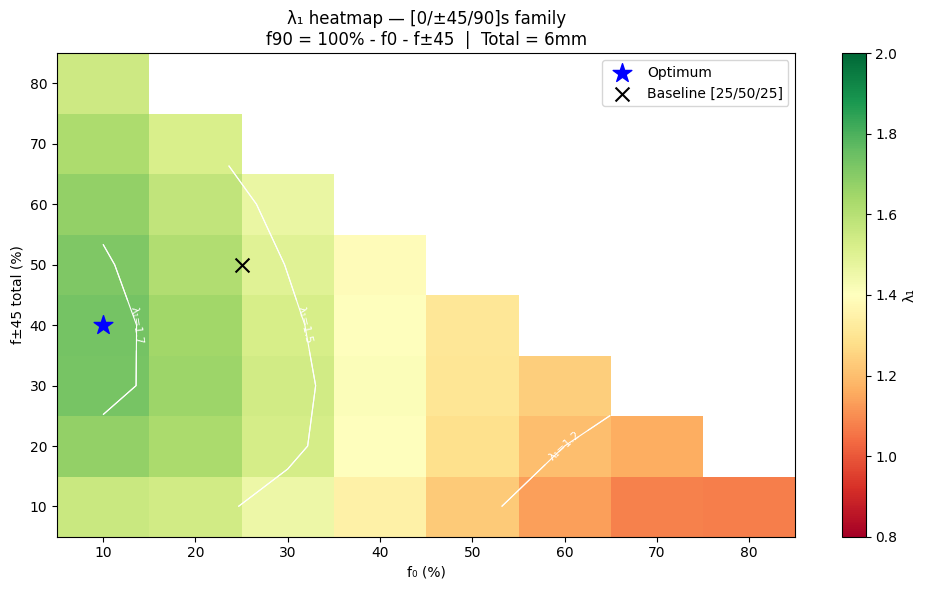

In [18]:
H = 6e-3
results_2d = []

print(f"{'f0%':>5} {'f±45%':>6} {'f90%':>6} {'t0':>7} {'t45':>7} {'t90':>7} {'λ₁':>8}")
print("-" * 60)

for f0_pct in range(10, 100, 10):
    for f45_pct in range(10, 100-f0_pct, 10):
        f90_pct = 100 - f0_pct - f45_pct

        if f90_pct < 5:
            continue

        f0  = f0_pct  / 100
        f45 = f45_pct / 100 / 2   # per ply (balance: t_+45 = t_-45)
        f90 = f90_pct / 100

        # Thickness per ply trong half-stack [0, 45, -45, 90]
        t0  = f0  * H / 2
        t45 = f45 * H / 2   # ← mỗi ply 45 và -45
        t90 = f90 * H / 2

        total = 2*(t0 + t45 + t45 + t90)
        if abs(total - H) > 1e-9:
            continue

        lam = compute_buckling_variable_thickness(t0, t45, t90)
        if lam is None:
            continue

        results_2d.append({
            "f0"     : f0_pct,
            "f45"    : f45_pct,
            "f90"    : f90_pct,
            "t0"     : t0,
            "t45"    : t45,
            "t90"    : t90,
            "lam"    : lam,
        })

        if MPI.COMM_WORLD.rank == 0:
            flag = "✅" if lam >= 1.0 else "❌"
            print(f"{flag} {f0_pct:>3}%  {f45_pct:>5}%  {f90_pct:>5}%  "
                  f"{t0*1e3:>6.2f}  {t45*1e3:>6.2f}  {t90*1e3:>6.2f}  "
                  f"{lam:>8.4f}")

# ─── Report ────────────────────────────────────────────────────────────────
if MPI.COMM_WORLD.rank == 0:
    results_2d.sort(key=lambda r: r["lam"], reverse=True)

    print("\n" + "=" * 60)
    print("TOP 5")
    print("=" * 60)
    for r in results_2d[:5]:
        flag = "✅" if r["lam"] >= 1.0 else "❌"
        print(f"  {flag} f0={r['f0']:>2}%  f±45={r['f45']:>2}%  f90={r['f90']:>2}%  "
              f"t0={r['t0']*1e3:.2f}mm  t45={r['t45']*1e3:.2f}mm  "
              f"t90={r['t90']*1e3:.2f}mm  λ₁={r['lam']:.4f}")

    best = results_2d[0]
    print(f"\n→ GLOBAL OPTIMUM")
    print(f"   f0   = {best['f0']}%   t0  = {best['t0']*1e3:.3f} mm/ply")
    print(f"   f±45 = {best['f45']}%  t45 = {best['t45']*1e3:.3f} mm/ply")
    print(f"   f90  = {best['f90']}%  t90 = {best['t90']*1e3:.3f} mm/ply")
    print(f"   λ₁   = {best['lam']:.4f}")
    print(f"   vs baseline [25/50/25]: {(best['lam']/1.5561-1)*100:+.1f}%")

    # Heatmap
    import matplotlib.pyplot as plt
    import numpy as np

    f0s  = sorted(set(r["f0"]  for r in results_2d))
    f45s = sorted(set(r["f45"] for r in results_2d))

    grid = np.full((len(f45s), len(f0s)), np.nan)
    for r in results_2d:
        i = f45s.index(r["f45"])
        j = f0s.index(r["f0"])
        grid[i, j] = r["lam"]

    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(grid, origin="lower", aspect="auto",
                   cmap="RdYlGn", vmin=0.8, vmax=2.0,
                   extent=[f0s[0]-5, f0s[-1]+5, f45s[0]-5, f45s[-1]+5])
    plt.colorbar(im, ax=ax, label="λ₁")

    # Mark optimum
    ax.scatter(best["f0"], best["f45"], s=200,
               color="blue", marker="*", zorder=5, label="Optimum")

    # Mark baseline
    ax.scatter(25, 50, s=100,
               color="black", marker="x", zorder=5, label="Baseline [25/50/25]")

    ax.contour(
        np.array(f0s), np.array(f45s), grid,
        levels=[1.0, 1.2, 1.5, 1.7],
        colors="white", linewidths=0.8
    )
    ax.clabel(ax.contour(
        np.array(f0s), np.array(f45s), grid,
        levels=[1.0, 1.2, 1.5, 1.7],
        colors="white", linewidths=0.8
    ), fmt="λ₁=%.1f", fontsize=8)

    ax.set_xlabel("f₀ (%)")
    ax.set_ylabel("f±45 total (%)")
    ax.set_title("λ₁ heatmap — [0/±45/90]s family\n"
                 "f90 = 100% - f0 - f±45  |  Total = 6mm")
    ax.legend()
    plt.tight_layout()
    plt.savefig("heatmap_2d.png", dpi=150)
    plt.show()
# ```

# ---

# ## Số evaluations và thời gian
# ```
# f0:  10,20,...,90     = 9 values
# f45: 5,10,...,varies  = ~8-15 values per f0 (giảm dần khi f0 tăng)
# Tổng feasible points  ≈ 70-80 evaluations

# Thời gian: 80 × 4 phút ≈ 5-6 tiếng

In [5]:
from mpi4py import MPI

comm = MPI.COMM_WORLD
rank = comm.rank


# ============================================================
# Candidate stacking sequences
# ============================================================

CANDIDATE_LAYUPS = {

    "Baseline_skin" :
        [0, 45, -45, 90, 90, -45, 45, 0],

    "More_0deg_skin" :
        [0, 0, 45, -45, -45, 45, 0, 0],

    "Shear_dominated" :
        [45, -45, 0, 90, 90, 0, -45, 45],

    "Quasi_isotropic" :
        [0, 45, -45, 90, 0, 45, -45, 90],

    "Buckling_oriented" :
        [0, 0, 45, -45, 90, 90, -45, 45],

    "Balanced_alt" :
        [45, 0, -45, 90, 90, -45, 0, 45],

}


# ============================================================
# Run comparison
# ============================================================

def evaluate_layups():

    results = []

    if rank == 0:
        print("\nSTACKING SEQUENCE COMPARISON")
        print("="*70)
        print(f"{'Name':<25} {'λ₁':>10} {'Layup'}")
        print("-"*70)

    for name, layup in CANDIDATE_LAYUPS.items():

        lambda_cr = compute_buckling_for_layup(layup)

        if lambda_cr is None:
            lambda_cr = 0.0

        results.append((name, layup, lambda_cr))

        if rank == 0:
            print(f"{name:<25} {lambda_cr:>10.4f}  {layup}")

    if rank == 0:

        results.sort(key=lambda r: r[2], reverse=True)

        print("\n" + "="*70)
        print("RANKING")
        print("="*70)

        for i,(name,layup,l) in enumerate(results):
            print(f"#{i+1:2d}  λ₁={l:.4f}  {name:<20} {layup}")

        best = results[0]

        print("\n" + "="*70)
        print("BEST CONFIGURATION")
        print("="*70)

        print(f"Name  : {best[0]}")
        print(f"Layup : {best[1]}")
        print(f"λ₁    : {best[2]:.4f}")


# ============================================================
# Run
# ============================================================

if __name__ == "__main__":
    evaluate_layups()


STACKING SEQUENCE COMPARISON
Name                              λ₁ Layup
----------------------------------------------------------------------
[CLT] Layup  : [0, 45, -45, 90, 90, -45, 45, 0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 9.82e-11  SYMMETRIC
[CLT] A11    : 458.21 MPa·m
[CLT] D11    : 2309.1921 N·m²
Baseline_skin                 1.5561  [0, 45, -45, 90, 90, -45, 45, 0]
[CLT] Layup  : [0, 0, 45, -45, -45, 45, 0, 0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 5.82e-11  SYMMETRIC
[CLT] A11    : 715.41 MPa·m
[CLT] D11    : 2991.0055 N·m²
More_0deg_skin                1.2995  [0, 0, 45, -45, -45, 45, 0, 0]
[CLT] Layup  : [45, -45, 0, 90, 90, 0, -45, 45]
[CLT] H      : 6.00 mm
[CLT] max|B| : 4.37e-11  SYMMETRIC
[CLT] A11    : 458.21 MPa·m
[CLT] D11    : 1253.2107 N·m²
Shear_dominated               1.9155  [45, -45, 0, 90, 90, 0, -45, 45]
[CLT] Layup  : [0, 45, -45, 90, 0, 45, -45, 90]
[CLT] H      : 6.00 mm
[CLT] max|B| : 2.89e+05  NON-SYMMETRIC
[CLT] A11    : 458.21 MPa·m
[CLT] D11    : 14